# Core Statistical Analysis — CryptoDiversify

## Pre-registered hypotheses (stated before looking at results)

**RQ1:** H0: average pairwise correlation is the same in calm vs. crash periods.
H1: correlation is significantly *higher* during crashes.

**RQ2:** H0: a diversified portfolio has the same volatility as a single coin.
H1: a diversified portfolio has *lower* volatility than a single coin.

**RQ3:** H0: an optimized (Markowitz) portfolio's Sharpe ratio is not meaningfully
different from equal-weighting. H1: the optimized portfolio achieves a *higher*
Sharpe ratio than equal-weighting — tested honestly out-of-sample, not just in-sample.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

corr_avg = pd.read_csv('../data/processed/correlation_avg_by_period.csv')
vol_comp = pd.read_csv('../data/processed/volatility_comparison.csv')
portfolio_comp = pd.read_csv('../data/processed/portfolio_comparison.csv')
weights = pd.read_csv('../data/processed/optimal_weights.csv')

## RQ1 — Does correlation spike during crashes?

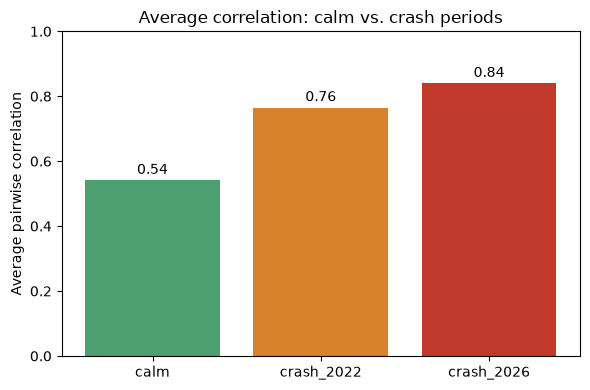

,period,n_days,avg_pairwise_correlation
0,calm,1669,0.540830
1,crash_2022,245,0.764987
2,crash_2026,181,0.839553


In [2]:
order = ['calm', 'crash_2022', 'crash_2026']
corr_avg = corr_avg.set_index('period').loc[order].reset_index()

plt.figure(figsize=(6,4))
bars = plt.bar(corr_avg['period'], corr_avg['avg_pairwise_correlation'],
               color=['#4C9F70', '#D9822B', '#C0392B'])
plt.ylim(0, 1)
plt.ylabel('Average pairwise correlation')
plt.title('Average correlation: calm vs. crash periods')
for b, v in zip(bars, corr_avg['avg_pairwise_correlation']):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()
display(corr_avg)

**Result:** average correlation rises from **0.54** (calm) to **0.77** (2022 crash) and
**0.84** (2026 crash) — supporting H1. This held across two very different crash causes
(crypto-specific in 2022, geopolitical/macro in 2026), which strengthens the finding beyond
a single event's quirk. **Plain-language conclusion:** diversification protection among
these coins shrinks exactly when an investor needs it most.

**Limitation:** crash windows were defined from known real-world events, not statistically
detected from the data — a defensible but judgment-based boundary choice (documented in
`PROJECT_BRIEF.md`).

## RQ2 — Does diversifying actually reduce risk?

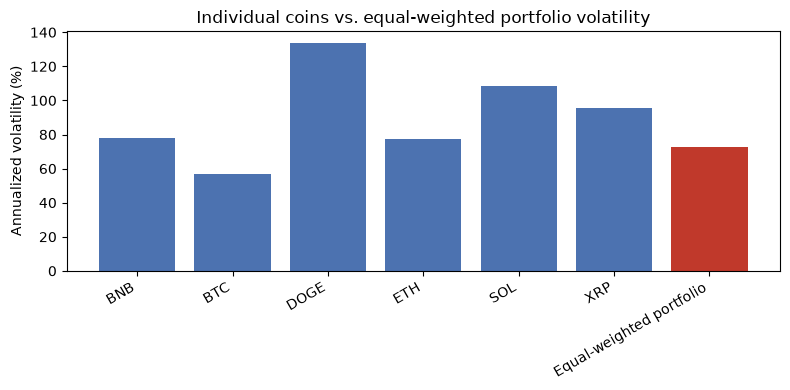

,asset,annualized_volatility
0,BNB,0.780462
1,BTC,0.571199
2,DOGE,1.338695
3,ETH,0.771837
4,SOL,1.087128
5,XRP,0.955418
6,Equal-weighted portfolio,0.725862


In [3]:
plt.figure(figsize=(8,4))
colors = ['#4C72B0']*6 + ['#C0392B']
plt.bar(vol_comp['asset'], vol_comp['annualized_volatility']*100, color=colors)
plt.ylabel('Annualized volatility (%)')
plt.title('Individual coins vs. equal-weighted portfolio volatility')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
display(vol_comp)

**Result:** the equal-weighted portfolio (72.6%) is less volatile than the *average*
individual coin (91.7%) — real diversification benefit versus a random pick. **But** it is
*more* volatile than Bitcoin alone (57.1%), the single safest coin. **Plain-language
conclusion:** diversifying helps versus an average/random coin, but — because these coins
are so correlated — it does not beat simply holding the historically safest single asset.

## RQ3 — Can Markowitz optimization beat naive allocation? (in-sample vs. honest out-of-sample)

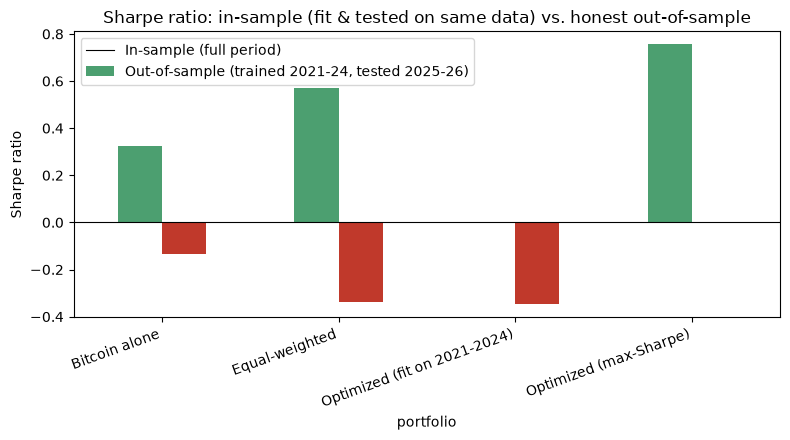

,analysis,portfolio,return,volatility,sharpe
0,in_sample_full_period,Optimized (max-Sharpe),0.609155,0.805861,0.755906
1,in_sample_full_period,Equal-weighted,0.415592,0.725862,0.572550
2,in_sample_full_period,Bitcoin alone,0.184650,0.571199,0.323267
3,out_of_sample_2025_2026,Optimized (fit on 2021-2024),-0.221276,0.635301,-0.348301
4,out_of_sample_2025_2026,Equal-weighted,-0.202628,0.602310,-0.336417
5,out_of_sample_2025_2026,Bitcoin alone,-0.057633,0.436690,-0.131977


In [4]:
pivot = portfolio_comp.pivot(index='portfolio', columns='analysis', values='sharpe')
pivot = pivot[['in_sample_full_period', 'out_of_sample_2025_2026']]

fig, ax = plt.subplots(figsize=(8,4.5))
pivot.plot(kind='bar', ax=ax, color=['#4C9F70', '#C0392B'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe ratio: in-sample (fit & tested on same data) vs. honest out-of-sample')
plt.xticks(rotation=20, ha='right')
plt.legend(['In-sample (full period)', 'Out-of-sample (trained 2021-24, tested 2025-26)'])
plt.tight_layout()
plt.show()
display(portfolio_comp)

**Result:** in-sample, the optimized portfolio looks best (Sharpe 0.76 vs. 0.57
equal-weighted vs. 0.32 Bitcoin-only) — but that's circular, since the weights were fit
using the very same data they're evaluated on. Once we split the data properly — fitting
weights on 2021-2024 only, then testing on unseen 2025-2026 data (which includes the 2026
crash) — the optimized portfolio's edge **disappears and reverses**: it performs *worse*
than equal-weighting, and both are dramatically worse than simply holding Bitcoin alone.

**Why:** Markowitz optimization is highly sensitive to estimation error in historical
average returns — it "chased" SOL/BNB/DOGE's strong 2021-2024 returns, and those same
coins were hit hardest in the 2026 crash. This mirrors a well-documented finding in
academic finance (DeMiguel, Garlappi & Uppal, 2009) that naive equal-weighting often beats
"optimized" portfolios out-of-sample.

**Plain-language conclusion:** a backward-looking "optimal" portfolio can look
impressive in hindsight while being fragile and overconfident going forward — a real
caution against over-trusting historical optimization in a fast-evolving asset class.

## Overall conclusions

1. **RQ1 confirmed:** correlation among these 6 coins rises sharply during crashes
   (0.54 -> 0.77-0.84), across two different crash causes.
2. **RQ2 nuanced:** diversifying helps vs. a random coin, but not vs. simply holding the
   historically safest single coin, because correlation limits real risk reduction.
3. **RQ3 — an honest caution:** Markowitz optimization looked strong in-sample but its
   edge reversed out-of-sample; naive equal-weighting and single-asset Bitcoin both held
   up better on truly unseen data.

## Limitations (see `PROJECT_BRIEF.md` for the full list)
- Six coins only, not the whole crypto market.
- Correlation does not imply causation.
- Crash windows were manually defined from known events, not statistically detected.
- Returns (not price levels) were used specifically to avoid spurious trend-driven
  correlation — confirmed empirically during this analysis.
- Risk-free rate assumed at 0% for Sharpe ratio calculations.
- No transaction costs, slippage, or exchange risk modeled.
- This is research for learning/portfolio purposes — **not financial advice**.